# Notebook 06 — Train, Tune, Evaluate

## Objective

Train and evaluate classification models for late-delivery prediction.

## Setup

- Prediction point: **Order approval time**
- Target: `late`
- Primary metric: **Average Precision (PR-AUC)**

## Evaluation

1. Train baseline and candidate models.
2. Compare them on the validation set.
3. Tune the Random Forest using validation performance.
4. Evaluate the selected model once on the test set.
5. Save the final model and evaluation artifacts.

The test set is not used for model selection or tuning.

In [56]:
import json
import joblib
import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

from sklearn.model_selection import ParameterGrid

In [57]:
# Define artifact paths

ARTIFACTS_DIR = Path("../artifacts")

NOTEBOOK_05_DIR = (
    ARTIFACTS_DIR / "notebook_05"
)

OUTPUT_DIR = (
    ARTIFACTS_DIR / "notebook_06"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FEATURE_LIST_PATH = (
    NOTEBOOK_05_DIR / "feature_list.json"
)

print(
    "Notebook 05 artifact directory:",
    NOTEBOOK_05_DIR.resolve()
)

print(
    "Notebook 06 output directory:",
    OUTPUT_DIR.resolve()
)

Notebook 05 artifact directory: C:\Users\Omex\Downloads\archive (1)\MLOps_Task1\artifacts\notebook_05
Notebook 06 output directory: C:\Users\Omex\Downloads\archive (1)\MLOps_Task1\artifacts\notebook_06


In [58]:
from pathlib import Path

NOTEBOOK_05_DIR = Path("../artifacts/notebook_05")

print("Notebook 05 artifact directory:")
print(NOTEBOOK_05_DIR.resolve())

print("\nFiles found:")
for file in sorted(NOTEBOOK_05_DIR.iterdir()):
    print(file.name)

Notebook 05 artifact directory:
C:\Users\Omex\Downloads\archive (1)\MLOps_Task1\artifacts\notebook_05

Files found:
artifact_manifest.csv
feature_list.csv
feature_list.json
feature_spec.json
notebook_05_summary.json
test_order_ids.parquet
train_order_ids.parquet
transformers
validation_order_ids.parquet
X_test.parquet
X_train.parquet
X_validation.parquet
y_test.parquet
y_train.parquet
y_validation.parquet


In [59]:
X_train = pd.read_parquet(
    NOTEBOOK_05_DIR / "X_train.parquet"
)

X_validation = pd.read_parquet(
    NOTEBOOK_05_DIR / "X_validation.parquet"
)

X_test = pd.read_parquet(
    NOTEBOOK_05_DIR / "X_test.parquet"
)

y_train = pd.read_parquet(
    NOTEBOOK_05_DIR / "y_train.parquet"
).squeeze()

y_validation = pd.read_parquet(
    NOTEBOOK_05_DIR / "y_validation.parquet"
).squeeze()

y_test = pd.read_parquet(
    NOTEBOOK_05_DIR / "y_test.parquet"
).squeeze()


print("Loaded processed datasets successfully.")
print()
print("Train:")
print("  X:", X_train.shape)
print("  y:", y_train.shape)

print("\nValidation:")
print("  X:", X_validation.shape)
print("  y:", y_validation.shape)

print("\nTest:")
print("  X:", X_test.shape)
print("  y:", y_test.shape)

Loaded processed datasets successfully.

Train:
  X: (67532, 50)
  y: (67532,)

Validation:
  X: (14472, 50)
  y: (14472,)

Test:
  X: (14472, 50)
  y: (14472,)


In [60]:
with open(
    FEATURE_LIST_PATH,
    "r",
    encoding="utf-8"
) as f:
    feature_list = json.load(f)

assert X_train.columns.tolist() == feature_list
assert X_validation.columns.tolist() == feature_list
assert X_test.columns.tolist() == feature_list

print("Feature alignment verified.")
print("Number of features:", len(feature_list))

Feature alignment verified.
Number of features: 50


In [61]:
for split_name, X in {
    "train": X_train,
    "validation": X_validation,
    "test": X_test,
}.items():

    assert X.isna().sum().sum() == 0, (
        f"{split_name}: NaN values detected."
    )

    assert np.isfinite(X.to_numpy()).all(), (
        f"{split_name}: infinite values detected."
    )

print(
    "Final feature matrices contain no NaN or infinite values."
)

Final feature matrices contain no NaN or infinite values.


In [62]:
assert set(y_train.unique()).issubset({0, 1})
assert set(y_validation.unique()).issubset({0, 1})
assert set(y_test.unique()).issubset({0, 1})

print("Train late rate:", y_train.mean())
print("Validation late rate:", y_validation.mean())
print("Test late rate:", y_test.mean())

Train late rate: 0.08113190783628502
Validation late rate: 0.08112216694306247
Test late rate: 0.08112216694306247


In [63]:
def evaluate_model(
    model,
    X,
    y,
    split_name
):
    """
    Evaluate a binary classifier.

    The positive class (1) represents a late delivery.
    Precision, recall, and F1 therefore refer to the
    Late class.
    """

    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    results = {
        "split": split_name,

        "accuracy": accuracy_score(
            y,
            y_pred
        ),

        "precision_late": precision_score(
            y,
            y_pred,
            pos_label=1,
            zero_division=0
        ),

        "recall_late": recall_score(
            y,
            y_pred,
            pos_label=1,
            zero_division=0
        ),

        "f1_late": f1_score(
            y,
            y_pred,
            pos_label=1,
            zero_division=0
        ),

        "roc_auc": roc_auc_score(
            y,
            y_prob
        ),

        "average_precision": average_precision_score(
            y,
            y_prob
        )
    }

    return results 

In [64]:
dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(
    X_train,
    y_train
)

dummy_results = evaluate_model(
    dummy_model,
    X_validation,
    y_validation,
     "validation"
)

dummy_results 

{'split': 'validation',
 'accuracy': 0.9188778330569375,
 'precision_late': 0.0,
 'recall_late': 0.0,
 'f1_late': 0.0,
 'roc_auc': 0.5,
 'average_precision': 0.08112216694306247}

In [65]:
logistic_baseline = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_baseline.fit(
    X_train,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [66]:
logistic_validation_results = evaluate_model(
    logistic_baseline,
    X_validation,
    y_validation,
    "validation"
)

logistic_validation_results

{'split': 'validation',
 'accuracy': 0.6713653952459923,
 'precision_late': 0.15872713414634146,
 'recall_late': 0.7095400340715503,
 'f1_late': 0.2594207412021177,
 'roc_auc': 0.7409523226328305,
 'average_precision': 0.20340669692321625}

In [67]:
baseline_results = pd.DataFrame(
    [
        {
            "model": "DummyClassifier",
            **dummy_results
        },
        {
            "model": "LogisticRegression",
            **logistic_validation_results
        }
    ]
)

baseline_results

,model,split,accuracy,precision_late,recall_late,f1_late,roc_auc,average_precision
0,DummyClassifier,validation,0.918878,0.000000,0.00000,0.000000,0.500000,0.081122
1,LogisticRegression,validation,0.671365,0.158727,0.70954,0.259421,0.740952,0.203407


In [68]:
rf_baseline = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(
    X_train,
    y_train
)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [69]:
rf_validation_results = evaluate_model(
    rf_baseline,
    X_validation,
    y_validation,
    "validation"
)

rf_validation_results

{'split': 'validation',
 'accuracy': 0.9194306246545052,
 'precision_late': 0.5606060606060606,
 'recall_late': 0.03151618398637138,
 'f1_late': 0.05967741935483871,
 'roc_auc': 0.7793568950051538,
 'average_precision': 0.2847213992239359}

In [70]:
baseline_results = pd.DataFrame(
    [
        {
            "model": "DummyClassifier",
            **dummy_results
        },
        {
            "model": "LogisticRegression",
            **logistic_validation_results
        },
        {
            "model": "RandomForestClassifier",
            **rf_validation_results
        }
    ]
)

baseline_results = (
    baseline_results
    .sort_values("average_precision", ascending=False)
    .reset_index(drop=True)
)

baseline_results

,model,split,accuracy,precision_late,recall_late,f1_late,roc_auc,average_precision
0,RandomForestClassifier,validation,0.919431,0.560606,0.031516,0.059677,0.779357,0.284721
1,LogisticRegression,validation,0.671365,0.158727,0.709540,0.259421,0.740952,0.203407
2,DummyClassifier,validation,0.918878,0.000000,0.000000,0.000000,0.500000,0.081122


In [71]:
rf_param_grid = {
    "n_estimators": [
        200,
        400
    ],

    "max_depth": [
        None,
        10,
        20
    ],

    "min_samples_leaf": [
        1,
        5,
        10
    ],

    "max_features": [
        "sqrt",
        "log2"
    ]
}

In [72]:
tuning_results = []

for params in ParameterGrid(
    rf_param_grid
):

    model = RandomForestClassifier(
        **params,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train
    )

    validation_result = evaluate_model(
        model,
        X_validation,
        y_validation,
         "validation"
    )

    validation_result.update(params)

    tuning_results.append(
        validation_result
    )

tuning_results = pd.DataFrame(
    tuning_results
)

tuning_results = tuning_results.sort_values(
     "average_precision",
    ascending=False
)

tuning_results.head(10) 

,split,accuracy,precision_late,recall_late,f1_late,roc_auc,average_precision,max_depth,max_features,min_samples_leaf,n_estimators
2,validation,0.897181,0.352720,0.320273,0.335714,0.792420,0.300076,NaN,sqrt,5,200
3,validation,0.896490,0.349722,0.321124,0.334813,0.792300,0.299303,NaN,sqrt,5,400
29,validation,0.865050,0.287507,0.448893,0.350515,0.789952,0.293488,20.0,sqrt,10,400
5,validation,0.873134,0.298906,0.419080,0.348936,0.791184,0.293417,NaN,sqrt,10,400
28,validation,0.864151,0.286408,0.452300,0.350727,0.788892,0.293190,20.0,sqrt,10,200
4,validation,0.872305,0.295012,0.413118,0.344216,0.790313,0.291909,NaN,sqrt,10,200
27,validation,0.881910,0.314365,0.385860,0.346463,0.790953,0.291627,20.0,sqrt,5,400
9,validation,0.890409,0.331974,0.346678,0.339167,0.791267,0.291286,NaN,log2,5,400
26,validation,0.882532,0.316084,0.385009,0.347158,0.789683,0.289928,20.0,sqrt,5,200
11,validation,0.865879,0.287299,0.441227,0.348001,0.787462,0.289520,NaN,log2,10,400


In [73]:
best_row = tuning_results.iloc[0]

best_params = {
    "n_estimators": int(
        best_row["n_estimators"]
    ),

    "max_depth": (
        None
        if pd.isna(best_row["max_depth"])
        else int(best_row["max_depth"])
    ),

    "min_samples_leaf": int(
        best_row["min_samples_leaf"]
    ),

    "max_features": best_row["max_features"]
}

best_params

{'n_estimators': 200,
 'max_depth': None,
 'min_samples_leaf': 5,
 'max_features': 'sqrt'}

In [74]:
final_model = RandomForestClassifier(
    **best_params,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    X_train,
    y_train
)

print("Final candidate model trained.")

Final candidate model trained.


In [75]:
final_validation_results = evaluate_model(
    final_model,
    X_validation,
    y_validation,
    "validation"
)

pd.DataFrame(
    [final_validation_results]
)

,split,accuracy,precision_late,recall_late,f1_late,roc_auc,average_precision
0,validation,0.897181,0.35272,0.320273,0.335714,0.79242,0.300076


In [76]:
final_test_results = evaluate_model(
    final_model,
    X_test,
    y_test,
    "test"
)

pd.DataFrame(
    [final_test_results]
)

,split,accuracy,precision_late,recall_late,f1_late,roc_auc,average_precision
0,test,0.896835,0.351628,0.321976,0.336149,0.789848,0.287124


In [77]:
y_test_pred = final_model.predict(
    X_test
)

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=[
            "On Time",
            "Late"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     On Time       0.94      0.95      0.94     13298
        Late       0.35      0.32      0.34      1174

    accuracy                           0.90     14472
   macro avg       0.65      0.63      0.64     14472
weighted avg       0.89      0.90      0.89     14472



In [78]:
cm = confusion_matrix(
    y_test,
    y_test_pred
)

cm

array([[12601,   697],
       [  796,   378]])

In [79]:
results_summary = {
    "prediction_point": "order_approval",

    "target": "late",

    "primary_metric": "average_precision",

    "baseline_models": [
        "DummyClassifier",
        "LogisticRegression",
        "RandomForestClassifier"
    ],

    "selected_model": "RandomForestClassifier",

    "best_parameters": best_params,

    "validation_results": final_validation_results,

    "test_results": final_test_results,

    "test_used_for_model_selection": False,

    "test_evaluated_once_at_end": True
}

with open(
    OUTPUT_DIR / "results_summary.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        results_summary,
        f,
        ensure_ascii=False,
        indent=2
    )

print("Results summary saved.")

Results summary saved.


In [80]:
MODEL_PATH = (
    OUTPUT_DIR / "final_model.joblib"
)

joblib.dump(
    final_model,
    MODEL_PATH
)

print(
    "Final model saved to:",
    MODEL_PATH
)

Final model saved to: ..\artifacts\notebook_06\final_model.joblib


In [81]:
tuning_results.to_csv(
    OUTPUT_DIR / "tuning_results.csv",
    index=False
)

pd.DataFrame(
    [final_validation_results]
).to_csv(
    OUTPUT_DIR / "validation_results.csv",
    index=False
)

pd.DataFrame(
    [final_test_results]
).to_csv(
    OUTPUT_DIR / "test_results.csv",
    index=False
)

print("Evaluation artifacts saved.")

Evaluation artifacts saved.


In [82]:
manifest = {
    "model": str(
        OUTPUT_DIR / "final_model.joblib"
    ),

    "results_summary": str(
        OUTPUT_DIR / "results_summary.json"
    ),

    "tuning_results": str(
        OUTPUT_DIR / "tuning_results.csv"
    ),

    "validation_results": str(
        OUTPUT_DIR / "validation_results.csv"
    ),

    "test_results": str(
        OUTPUT_DIR / "test_results.csv"
    )
}

with open(
    OUTPUT_DIR / "artifact_manifest.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        manifest,
        f,
        ensure_ascii=False,
        indent=2
    )

print("Notebook 06 artifacts are ready.")

Notebook 06 artifacts are ready.


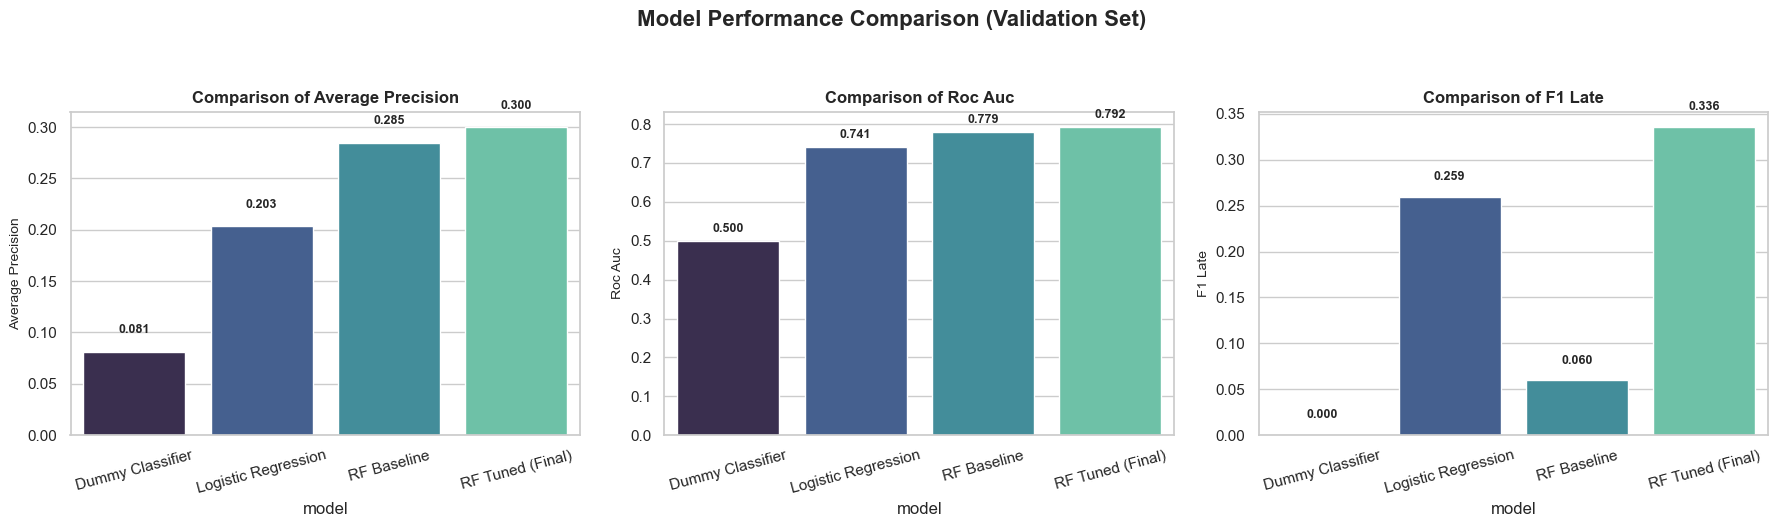

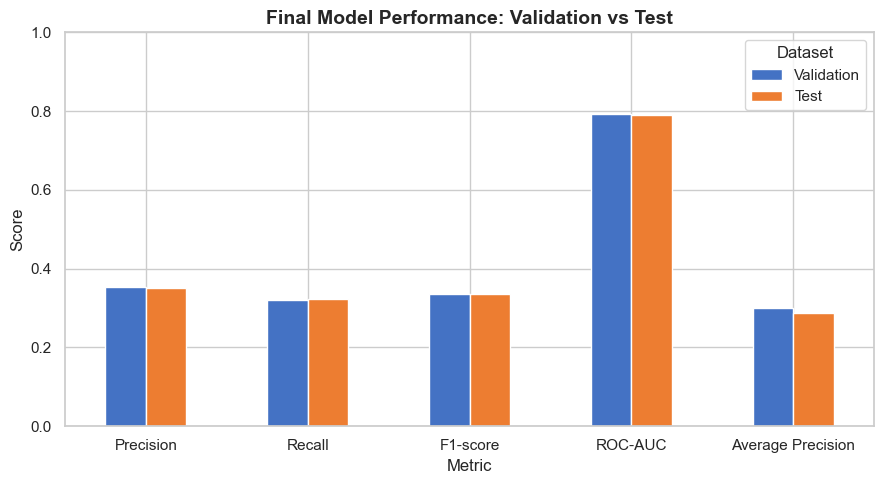

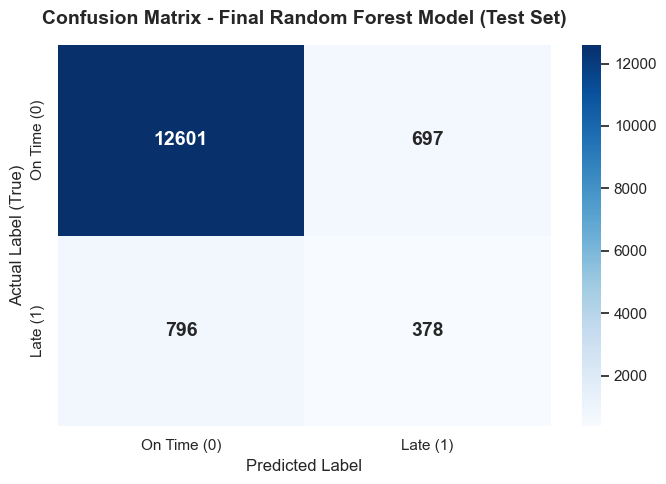

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

models_to_compare = {
    "Dummy Classifier": dummy_results,
    "Logistic Regression": logistic_validation_results,
    "RF Baseline": rf_validation_results,
    "RF Tuned (Final)": final_validation_results
}

metrics_to_plot = ["average_precision", "roc_auc", "f1_late"]
model_names = list(models_to_compare.keys())

fig1, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, metric in enumerate(metrics_to_plot):
    plot_data = pd.DataFrame({
        'model': model_names,
        'value': [models_to_compare[model][metric] for model in model_names]
    })
    
    sns.barplot(
        data=plot_data,
        x='model',
        y='value',
        ax=axes[i],
        palette="mako",
        hue='model',
        legend=False
    )
    
    metric_title = metric.replace('_', ' ').title()
    axes[i].set_title(f"Comparison of {metric_title}", fontsize=12, fontweight='bold')
    axes[i].set_ylabel(metric_title, fontsize=10)
    axes[i].tick_params(axis='x', rotation=15)
    
    for j, v in enumerate(plot_data['value']):
        axes[i].text(j, v + 0.015, f"{v:.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle("Model Performance Comparison (Validation Set)", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

validation_metrics = {
    "Precision": final_validation_results["precision_late"],
    "Recall": final_validation_results["recall_late"],
    "F1-score": final_validation_results["f1_late"],
    "ROC-AUC": final_validation_results["roc_auc"],
    "Average Precision": final_validation_results["average_precision"]
}

test_metrics = {
    "Precision": final_test_results["precision_late"],
    "Recall": final_test_results["recall_late"],
    "F1-score": final_test_results["f1_late"],
    "ROC-AUC": final_test_results["roc_auc"],
    "Average Precision": final_test_results["average_precision"]
}

metrics_df = pd.DataFrame({
    "Validation": validation_metrics,
    "Test": test_metrics
})

fig2 = metrics_df.plot(
    kind="bar",
    figsize=(9, 5),
    color=['#4472C4', '#ED7D31']
)

plt.ylabel("Score")
plt.xlabel("Metric")
plt.title("Final Model Performance: Validation vs Test", fontsize=14, fontweight='bold')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

fig3 = plt.figure(figsize=(7, 5))

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=['On Time (0)', 'Late (1)'], 
    yticklabels=['On Time (0)', 'Late (1)'],
    annot_kws={"size": 14, "weight": "bold"}
)

plt.title('Confusion Matrix - Final Random Forest Model (Test Set)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual Label (True)', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()